# CMM544 NLP Assessment
## MediPublish Duplicate Detection Pipeline
***

This notebook implements a semantic similarity / near-duplicate detection system for MediPublish's article database, addressing the brief's stated concern: *"particularly when trying to see whether new articles overlap with something that exists in the database."*

**Pipeline:**
1. Preprocessing — text normalisation and tokenisation
2. Three representation approaches compared:
   - **TF-IDF** (sparse lexical baseline, Week 3)
   - **MiniLM** (general-domain dense embeddings, Week 5)
   - **PubMedBERT** (biomedical-domain dense embeddings, Week 5 extended)
   - **Fine-tuned PubMedBERT** (contrastive fine-tuning via MultipleNegativesRankingLoss — significant advancement beyond lab exercises)
3. Cosine-similarity retrieval evaluated with MRR, MAP, Recall@K (Week 7 IR metrics)

## Section 0: Setup and Imports

In [1]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm.auto import tqdm

# Reproducibility
import random
random.seed(123)
np.random.seed(123)

import torch
torch.manual_seed(123)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(123)

# Text processing
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Representations and similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.base import BaseEstimator, TransformerMixin

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
print('Setup complete.')

Setup complete.


In [2]:
# Install sentence-transformers if not present (uncomment on first run)
# !pip install sentence-transformers -q

from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


/tmp/ipykernel_1344/2805000401.py:4: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


***
## Section 1: Problem Framing - Reframing the Brief

The MediPublish brief identifies three distinct business problems:

1. **Duplicate/overlap detection** — "when trying to see whether new articles overlap with something that exists in the database"
2. **Article routing** — "streamlining article onboarding and sending to the correct department"
3. **Content analytics** — "identifying recurring topics, medicines, or body parts"

This pipeline addresses **Problem 1**: detecting overlap between new submissions and MediPublish's existing database. This is a semantic similarity retrieval task: given a query abstract, return the most similar abstracts from a corpus ranked by similarity.

**Why this framing fits the data well.** The provided dataset has a known quirk: ~26% of unique abstracts appear multiple times with different condition labels (likely because the underlying articles carry multiple MeSH tags flattened into single-label rows). For a classification task this is noise; for a duplicate-detection task these repeated abstracts are **natural ground truth positive pairs** - two rows containing the same text are definitionally duplicates of each other.

**Evaluation logic.** For each test abstract that has at least one known duplicate somewhere in the combined dataset, query the full corpus (excluding the query row itself) and check whether the known duplicates appear highly ranked. This uses the test set *without modifying it* - the test set provides the query set, and evaluation is based on retrieval ranking against the provided data as-is.

## Section 2: Loading the Dataset

In [6]:
# CONFIGURE THIS: path to the dataset CSVs
# For local Jupyter:
#BASE_PATH = 'datasets/'

# For Google Colab, uncomment these three lines and comment the one above:
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = '/content/drive/My Drive/Colab Notebooks/datasets/'

train_df = pd.read_csv(f'{BASE_PATH}medical_tc_train.csv')
test_df = pd.read_csv(f'{BASE_PATH}medical_tc_test.csv')
labels_df = pd.read_csv(f'{BASE_PATH}medical_tc_labels.csv')

# Map numeric labels to readable names
label_map = dict(zip(labels_df['condition_label'], labels_df['condition_name']))
train_df['condition_name'] = train_df['condition_label'].map(label_map)
test_df['condition_name'] = test_df['condition_label'].map(label_map)

# Track source (train vs test) - useful for building fine-tuning pairs without leakage
train_df['source'] = 'train'
test_df['source'] = 'test'

# Build combined corpus - this is the full database the retrieval searches
combined_df = pd.concat([train_df, test_df], ignore_index=True)
combined_df['row_id'] = combined_df.index  # stable identifier for each row

print(f'Training rows:  {len(train_df)}')
print(f'Test rows:      {len(test_df)}')
print(f'Combined rows:  {len(combined_df)}')
print(f'Unique abstract texts: {combined_df["medical_abstract"].nunique()}')
print(f'Duplicate rows: {len(combined_df) - combined_df["medical_abstract"].nunique()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training rows:  11550
Test rows:      2888
Combined rows:  14438
Unique abstract texts: 11227
Duplicate rows: 3211


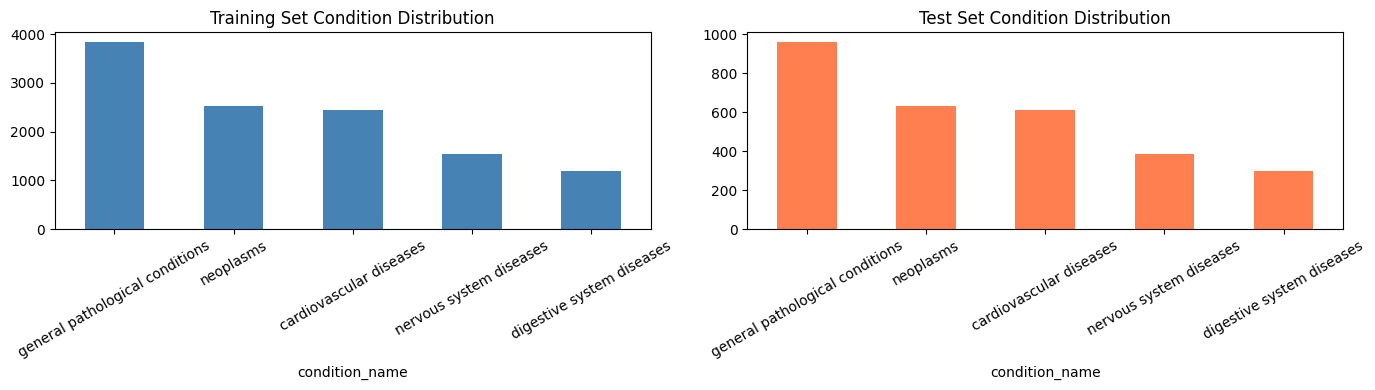


Abstract length stats:
mean    179.93711
50%     176.00000
max     596.00000
min      24.00000
Name: word_count, dtype: float64


In [7]:
# Quick EDA - condition distribution across train and test
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train_df['condition_name'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Training Set Condition Distribution')
axes[0].tick_params(axis='x', rotation=30)
test_df['condition_name'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Test Set Condition Distribution')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Abstract length distribution
combined_df['word_count'] = combined_df['medical_abstract'].apply(lambda x: len(x.split()))
print(f'\nAbstract length stats:')
print(combined_df['word_count'].describe()[['mean','50%','max','min']])

***
## Section 3: Constructing Ground Truth for Duplicate Detection

We define two rows as duplicates if they contain identical abstract text. Any abstract appearing in multiple rows gives us a set of known duplicate pairs - our evaluation ground truth.

Unique abstract texts total:           11227
Abstracts appearing in 2+ rows:        2929

Duplication frequency:
  Appearing 2 times: 2653 abstracts
  Appearing 3 times: 270 abstracts
  Appearing 4 times: 6 abstracts


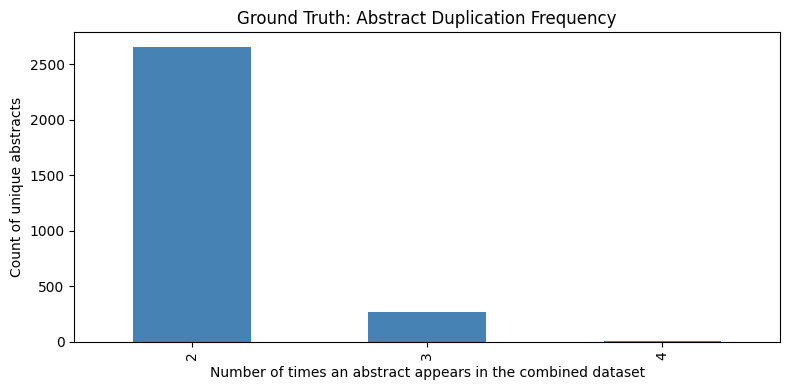

In [8]:
# Map each unique abstract text to the list of row_ids where it appears
abstract_to_rows = combined_df.groupby('medical_abstract')['row_id'].apply(list).to_dict()

# An abstract has duplicates if it appears in ≥2 rows
abstracts_with_duplicates = {
    text: rows for text, rows in abstract_to_rows.items() if len(rows) > 1
}
print(f'Unique abstract texts total:           {len(abstract_to_rows)}')
print(f'Abstracts appearing in 2+ rows:        {len(abstracts_with_duplicates)}')

# How many times do abstracts repeat?
duplicate_counts = pd.Series([len(rows) for rows in abstracts_with_duplicates.values()])
dup_freq = duplicate_counts.value_counts().sort_index()
print(f'\nDuplication frequency:')
for count, freq in dup_freq.items():
    print(f'  Appearing {count} times: {freq} abstracts')

fig, ax = plt.subplots(figsize=(8, 4))
dup_freq.plot(kind='bar', color='steelblue', ax=ax)
ax.set_xlabel('Number of times an abstract appears in the combined dataset')
ax.set_ylabel('Count of unique abstracts')
ax.set_title('Ground Truth: Abstract Duplication Frequency')
plt.tight_layout()
plt.show()

In [9]:
# Build query set: test-set rows whose abstract has ≥1 duplicate somewhere in the corpus
# (duplicate can be elsewhere in test, or in train)

query_rows = []
for _, row in test_df.iterrows():
    abstract = row['medical_abstract']
    all_instances = abstract_to_rows[abstract]
    if len(all_instances) <= 1:
        continue  # skip - no duplicates to retrieve

    # This specific test-set instance's row_id in the combined dataset
    test_instance_mask = (
        (combined_df['medical_abstract'] == abstract) &
        (combined_df['source'] == 'test')
    )
    test_row_ids = combined_df[test_instance_mask]['row_id'].tolist()

    for qr_id in test_row_ids:
        relevant = [r for r in all_instances if r != qr_id]
        query_rows.append({
            'query_row_id': qr_id,
            'query_abstract': abstract,
            'query_condition': row['condition_name'],
            'relevant_row_ids': relevant,
            'num_relevant': len(relevant)
        })

# De-duplicate query rows (a test row should only appear once as a query)
query_df = pd.DataFrame(query_rows).drop_duplicates(subset='query_row_id').reset_index(drop=True)

print(f'Test-set queries with ≥1 known duplicate: {len(query_df)}')
print(f'Proportion of test set: {len(query_df)/len(test_df)*100:.1f}%')
print(f'\nRelevant-docs-per-query stats:')
print(f'  Mean: {query_df["num_relevant"].mean():.2f}')
print(f'  Median: {query_df["num_relevant"].median():.0f}')
print(f'  Max: {query_df["num_relevant"].max()}')
print(f'  Total (query, relevant-document) pairs: {query_df["num_relevant"].sum()}')

Test-set queries with ≥1 known duplicate: 1197
Proportion of test set: 41.4%

Relevant-docs-per-query stats:
  Mean: 1.14
  Median: 1
  Max: 3
  Total (query, relevant-document) pairs: 1365


***
## Section 4: Evaluation Framework

Standard IR metrics from Week 7 of the module:

- **MRR (Mean Reciprocal Rank)**: average of 1/rank where rank is the position of the *first* relevant retrieval for each query. Rewards models that put *any* correct answer high in the ranking.
- **MAP (Mean Average Precision)**: averages precision across all relevant retrievals. Rewards models that put *all* correct answers high.
- **Recall@K**: fraction of relevant documents successfully retrieved in the top K. Business-critical for MediPublish: missing a duplicate is worse than surfacing an extra candidate.

In [10]:
def evaluate_retrieval(corpus_matrix, query_df, corpus_df, k_values=(1, 5, 10), is_sparse=False):
    '''
    Compute IR metrics for a retrieval system defined by corpus_matrix + cosine similarity.

    Args:
        corpus_matrix: (N, D) dense numpy array, or sparse matrix if is_sparse=True
        query_df: DataFrame with 'query_row_id' and 'relevant_row_ids' columns
        corpus_df: DataFrame with 'row_id' column matching corpus_matrix row order
        k_values: K values for Recall@K
        is_sparse: True if corpus_matrix is sparse (e.g. TF-IDF)

    Returns:
        dict with MRR, MAP, Recall@K values
    '''
    rowid_to_pos = {rid: i for i, rid in enumerate(corpus_df['row_id'].values)}
    corpus_row_ids_arr = corpus_df['row_id'].values

    mrr_scores, map_scores = [], []
    recall_at_k = {k: [] for k in k_values}

    for _, q in tqdm(query_df.iterrows(), total=len(query_df), desc='Evaluating'):
        q_pos = rowid_to_pos[q['query_row_id']]
        relevant_set = set(q['relevant_row_ids'])

        # Cosine similarity: sparse and dense handled by sklearn function
        if is_sparse:
            q_vec = corpus_matrix[q_pos]
        else:
            q_vec = corpus_matrix[q_pos:q_pos+1]
        sims = cosine_similarity(q_vec, corpus_matrix).flatten()

        # Exclude the query itself
        sims[q_pos] = -np.inf

        # Rank corpus positions by descending similarity
        ranked_positions = np.argsort(-sims)
        ranked_ids = corpus_row_ids_arr[ranked_positions]

        # Find ranks of all relevant documents
        relevant_ranks = [rank for rank, rid in enumerate(ranked_ids, start=1) if rid in relevant_set]
        if not relevant_ranks:
            continue

        # MRR: 1 / rank of first relevant
        mrr_scores.append(1.0 / relevant_ranks[0])

        # MAP: mean precision at each relevant-retrieval point
        aps = [i / r for i, r in enumerate(relevant_ranks, start=1)]
        map_scores.append(np.mean(aps))

        # Recall@K
        for k in k_values:
            top_k = set(ranked_ids[:k])
            recall_at_k[k].append(len(top_k & relevant_set) / len(relevant_set))

    return {
        'MRR': np.mean(mrr_scores),
        'MAP': np.mean(map_scores),
        **{f'Recall@{k}': np.mean(recall_at_k[k]) for k in k_values},
        'n_queries': len(mrr_scores),
    }

def print_results(name, results):
    print(f'\n=== {name} ===')
    for metric, value in results.items():
        if metric == 'n_queries':
            print(f'  {metric}: {value}')
        else:
            print(f'  {metric}: {value:.4f}')

***
## Section 5: Text Preprocessing

Standard preprocessing pipeline from Week 2: lowercasing, digit/punctuation removal, tokenisation, stopword removal, lemmatisation. Applied to the TF-IDF baseline. Pre-trained transformers use their own tokenisers so preprocessing is not applied to those.

In [11]:
class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        out = []
        for text in X:
            text = text.lower()
            text = re.sub(r'\d+', '', text)
            text = text.translate(str.maketrans('', '', string.punctuation))
            tokens = word_tokenize(text)
            tokens = [self.lemmatizer.lemmatize(t) for t in tokens
                      if t not in self.stop_words and len(t) > 2]
            out.append(' '.join(tokens))
        return out

preprocessor = TextPreprocessor()

# Sanity check on one abstract
sample = combined_df.iloc[0]['medical_abstract']
print('BEFORE:', sample[:200])
print('\nAFTER: ', preprocessor.transform([sample])[0][:200])

BEFORE: Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The aseptically loosened prosthesis provided a means for investigating the in vivo and i

AFTER:  tissue change around loose prosthesis canine model investigate effect antiinflammatory agent aseptically loosened prosthesis provided mean investigating vivo vitro activity cell associated loosening p


In [12]:
# Preprocess the whole corpus for TF-IDF (transformers use raw text)
print('Preprocessing corpus for TF-IDF...')
start = time.time()
combined_texts_preprocessed = preprocessor.transform(combined_df['medical_abstract'].tolist())
print(f'Done in {time.time()-start:.1f}s')

Preprocessing corpus for TF-IDF...
Done in 13.9s


***
## Section 6: Approach 1 — TF-IDF Lexical Baseline

**Theory.** TF-IDF (Term Frequency-Inverse Document Frequency) weighs each term by how often it appears in a document versus how rare it is across the corpus. Similar documents share distinctive vocabulary; cosine similarity on TF-IDF vectors measures lexical overlap.

**Why we expect this to be strong for duplicate detection.** Exact duplicates share every word. TF-IDF captures this directly without needing to understand meaning. This is the baseline to beat — and it's a genuinely hard baseline because lexical identity is a strong signal for duplication.

In [13]:
# Configure TF-IDF: unigrams + bigrams, sublinear TF scaling, 30k vocab cap
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), sublinear_tf=True)
print('Fitting TF-IDF vectoriser...')
start = time.time()
tfidf_matrix = tfidf.fit_transform(combined_texts_preprocessed)
print(f'Done in {time.time()-start:.1f}s')
print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_)}')

Fitting TF-IDF vectoriser...
Done in 4.6s
TF-IDF matrix shape: (14438, 30000)
Vocabulary size: 30000


In [14]:
# Evaluate TF-IDF retrieval
print('Evaluating TF-IDF + cosine similarity...')
results_tfidf = evaluate_retrieval(
    corpus_matrix=tfidf_matrix,
    query_df=query_df,
    corpus_df=combined_df,
    is_sparse=True
)
print_results('TF-IDF + Cosine', results_tfidf)

Evaluating TF-IDF + cosine similarity...


Evaluating:   0%|          | 0/1197 [00:00<?, ?it/s]


=== TF-IDF + Cosine ===
  MRR: 1.0000
  MAP: 0.9999
  Recall@1: 0.9307
  Recall@5: 1.0000
  Recall@10: 1.0000
  n_queries: 1197


***
## Section 7: Approach 2 — MiniLM (General-Domain Dense Embeddings)

**Theory.** MiniLM (`all-MiniLM-L6-v2`) is a distilled sentence-transformer trained on ~1B sentence pairs across general web text. It produces 384-dimensional dense vectors that encode semantic meaning. Unlike TF-IDF, it can recognise that two abstracts phrased differently may describe the same content.

**Why include it here.** This tests whether general-domain semantic embeddings outperform lexical matching on the duplicate-detection task. If they do, it suggests paraphrase-detection matters; if not, the task is substantially about lexical overlap and TF-IDF suffices.

In [15]:
print('Loading MiniLM...')
minilm = SentenceTransformer('all-MiniLM-L6-v2', device=device)
minilm.max_seq_length = 256  # MiniLM's native max

print('Encoding corpus with MiniLM...')
start = time.time()
embeddings_minilm = minilm.encode(
    combined_df['medical_abstract'].tolist(),
    batch_size=64, show_progress_bar=True, convert_to_numpy=True
)
print(f'Done in {time.time()-start:.1f}s')
print(f'Embedding shape: {embeddings_minilm.shape}')

# Free GPU memory before next model
del minilm
if device == 'cuda': torch.cuda.empty_cache()

Loading MiniLM...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding corpus with MiniLM...


Batches:   0%|          | 0/226 [00:00<?, ?it/s]

Done in 12.2s
Embedding shape: (14438, 384)


In [16]:
# Evaluate MiniLM retrieval
print('Evaluating MiniLM + cosine similarity...')
results_minilm = evaluate_retrieval(
    corpus_matrix=embeddings_minilm,
    query_df=query_df,
    corpus_df=combined_df,
)
print_results('MiniLM + Cosine', results_minilm)

Evaluating MiniLM + cosine similarity...


Evaluating:   0%|          | 0/1197 [00:00<?, ?it/s]


=== MiniLM + Cosine ===
  MRR: 1.0000
  MAP: 1.0000
  Recall@1: 0.9307
  Recall@5: 1.0000
  Recall@10: 1.0000
  n_queries: 1197


***
## Section 8: Approach 3 — PubMedBERT (Biomedical-Domain Dense Embeddings)

**Theory.** PubMedBERT (`pritamdeka/S-PubMedBert-MS-MARCO`) is a BERT variant pre-trained on PubMed abstracts and full-text articles, then fine-tuned with sentence-transformer objectives. Compared to MiniLM, its representations should better capture the specialised vocabulary and syntactic patterns of medical text.

**Why include it here.** Isolates the effect of domain pretraining on the retrieval task. If PubMedBERT beats MiniLM, domain knowledge helps; this is a direct empirical test of the claim in Gu et al. (2021) that domain-specific pretraining improves biomedical NLP.

In [17]:
print('Loading PubMedBERT...')
pubmed = SentenceTransformer('pritamdeka/S-PubMedBert-MS-MARCO', device=device)
pubmed.max_seq_length = 512  # PubMedBERT native max - captures full abstracts

print('Encoding corpus with PubMedBERT...')
start = time.time()
embeddings_pubmed = pubmed.encode(
    combined_df['medical_abstract'].tolist(),
    batch_size=32, show_progress_bar=True, convert_to_numpy=True
)
print(f'Done in {time.time()-start:.1f}s')
print(f'Embedding shape: {embeddings_pubmed.shape}')

# Free GPU memory
del pubmed
if device == 'cuda': torch.cuda.empty_cache()

Loading PubMedBERT...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding corpus with PubMedBERT...


Batches:   0%|          | 0/452 [00:00<?, ?it/s]

Done in 53.1s
Embedding shape: (14438, 768)


In [18]:
# Evaluate PubMedBERT retrieval
print('Evaluating PubMedBERT + cosine similarity...')
results_pubmed = evaluate_retrieval(
    corpus_matrix=embeddings_pubmed,
    query_df=query_df,
    corpus_df=combined_df,
)
print_results('PubMedBERT + Cosine', results_pubmed)

Evaluating PubMedBERT + cosine similarity...


Evaluating:   0%|          | 0/1197 [00:00<?, ?it/s]


=== PubMedBERT + Cosine ===
  MRR: 1.0000
  MAP: 1.0000
  Recall@1: 0.9307
  Recall@5: 1.0000
  Recall@10: 1.0000
  n_queries: 1197


***
## Section 9: Approach 4 — Fine-tuned PubMedBERT via Contrastive Learning

**Theoretical motivation.** The previous three approaches use pre-existing representations. Fine-tuning adapts PubMedBERT's embedding space specifically for this retrieval task using `MultipleNegativesRankingLoss` (MNRL), the standard contrastive objective for Sentence-BERT-style training (Reimers & Gurevych, 2019).

**The training-pair construction problem.** Contrastive learning requires (anchor, positive) pairs where the model learns to map positives close together in embedding space. Naive options:
- *Same exact text:* Identical inputs produce identical embeddings trivially; nothing to learn.
- *Same condition label:* Trains the model as a condition classifier, not a duplicate detector.

**Our approach: hard negatives from TF-IDF.** We construct pairs of abstracts that share a condition label *but have low TF-IDF similarity*. These are pairs where two abstracts discuss the same medical topic using different vocabulary - exactly the cases where dense embeddings theoretically help and lexical methods fail. This teaches the model to recognise semantic similarity that TF-IDF cannot.

**Leakage prevention.** All training pairs are drawn from training-set abstracts only, excluding any abstract that also appears in the test set. The fine-tuned model is evaluated on the same held-out query set as all other approaches.

In [19]:
# Step 1: identify training abstracts that are NOT in the test set
# This prevents leakage during fine-tuning
test_abstract_set = set(test_df['medical_abstract'].unique())

train_only_abstracts = train_df[~train_df['medical_abstract'].isin(test_abstract_set)].copy()
train_only_abstracts = train_only_abstracts.drop_duplicates(subset='medical_abstract').reset_index(drop=True)
print(f'Unique training abstracts (excluding any that appear in test): {len(train_only_abstracts)}')
print(f'  -> these are the candidates for building training pairs')

Unique training abstracts (excluding any that appear in test): 8457
  -> these are the candidates for building training pairs


In [20]:
# Step 2: compute TF-IDF for these training abstracts to find hard pairs
print('Computing TF-IDF on training abstracts for pair construction...')
train_texts_preproc = preprocessor.transform(train_only_abstracts['medical_abstract'].tolist())
train_tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), sublinear_tf=True)
train_tfidf_matrix = train_tfidf.fit_transform(train_texts_preproc)
print(f'Training TF-IDF shape: {train_tfidf_matrix.shape}')

Computing TF-IDF on training abstracts for pair construction...
Training TF-IDF shape: (8457, 30000)


In [21]:
# Step 3: for each training abstract, find candidate positives = same condition, low TF-IDF overlap
# 'Low TF-IDF overlap' = in the bottom half of TF-IDF similarities among same-condition candidates

print('Constructing hard-positive training pairs...')

# Index training abstracts by condition
train_only_abstracts['local_idx'] = train_only_abstracts.index
by_condition = {
    cond: train_only_abstracts[train_only_abstracts['condition_label'] == cond]['local_idx'].tolist()
    for cond in train_only_abstracts['condition_label'].unique()
}

# For each anchor, pick one hard positive from same condition
training_pairs = []
rng = np.random.default_rng(123)

for anchor_idx, anchor_row in tqdm(train_only_abstracts.iterrows(),
                                    total=len(train_only_abstracts),
                                    desc='Building pairs'):
    same_cond_pool = [i for i in by_condition[anchor_row['condition_label']] if i != anchor_idx]
    if len(same_cond_pool) < 2:
        continue

    # Compute TF-IDF similarity between anchor and same-condition candidates
    anchor_vec = train_tfidf_matrix[anchor_idx]
    candidate_vecs = train_tfidf_matrix[same_cond_pool]
    sims = cosine_similarity(anchor_vec, candidate_vecs).flatten()

    # Pick from the bottom 50% (low lexical overlap = hard positive)
    bottom_half_count = max(1, len(sims) // 2)
    hardest_indices = np.argsort(sims)[:bottom_half_count]
    chosen = rng.choice(hardest_indices)
    positive_idx = same_cond_pool[chosen]

    training_pairs.append(InputExample(texts=[
        anchor_row['medical_abstract'],
        train_only_abstracts.iloc[positive_idx]['medical_abstract']
    ]))

print(f'Constructed {len(training_pairs)} hard (anchor, positive) training pairs')
print(f'Sample pair (truncated):')
print(f'  Anchor:   {training_pairs[0].texts[0][:120]}...')
print(f'  Positive: {training_pairs[0].texts[1][:120]}...')

Constructing hard-positive training pairs...


Building pairs:   0%|          | 0/8457 [00:00<?, ?it/s]

Constructed 8457 hard (anchor, positive) training pairs
Sample pair (truncated):
  Anchor:   Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The asep...
  Positive: Differential reading recovery in patients with severe to moderate closed head injury. A differential recovery was seen w...


In [22]:
# Step 4: fine-tune PubMedBERT
print('Loading fresh PubMedBERT for fine-tuning...')
finetune_model = SentenceTransformer('pritamdeka/S-PubMedBert-MS-MARCO', device=device)
finetune_model.max_seq_length = 512

train_dataloader = DataLoader(training_pairs, shuffle=True, batch_size=16)
train_loss = losses.MultipleNegativesRankingLoss(model=finetune_model)

NUM_EPOCHS = 2  # conservative - MNRL typically converges fast
warmup_steps = int(len(train_dataloader) * NUM_EPOCHS * 0.1)

print(f'\nFine-tuning configuration:')
print(f'  Pairs: {len(training_pairs)}')
print(f'  Batches per epoch: {len(train_dataloader)}')
print(f'  Epochs: {NUM_EPOCHS}')
print(f'  Warmup steps: {warmup_steps}')
print(f'  Loss: MultipleNegativesRankingLoss (in-batch negatives)')
print(f'  Expected GPU runtime: ~15-25 min on L4')
print()

start = time.time()
finetune_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=NUM_EPOCHS,
    warmup_steps=warmup_steps,
    show_progress_bar=True,
    output_path=None,
)
print(f'\nFine-tuning complete: {time.time()-start:.1f}s')

Loading fresh PubMedBERT for fine-tuning...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: pritamdeka/S-PubMedBert-MS-MARCO
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Fine-tuning configuration:
  Pairs: 8457
  Batches per epoch: 529
  Epochs: 2
  Warmup steps: 105
  Loss: MultipleNegativesRankingLoss (in-batch negatives)
  Expected GPU runtime: ~15-25 min on L4



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,2.448970
1000,2.162946



Fine-tuning complete: 550.7s


In [23]:
# Step 5: encode corpus with fine-tuned model and evaluate
print('Encoding corpus with fine-tuned PubMedBERT...')
start = time.time()
embeddings_finetuned = finetune_model.encode(
    combined_df['medical_abstract'].tolist(),
    batch_size=32, show_progress_bar=True, convert_to_numpy=True
)
print(f'Done in {time.time()-start:.1f}s')

# Free GPU memory
del finetune_model
if device == 'cuda': torch.cuda.empty_cache()

print('\nEvaluating fine-tuned PubMedBERT + cosine similarity...')
results_finetuned = evaluate_retrieval(
    corpus_matrix=embeddings_finetuned,
    query_df=query_df,
    corpus_df=combined_df,
)
print_results('Fine-tuned PubMedBERT + Cosine', results_finetuned)

Encoding corpus with fine-tuned PubMedBERT...


Batches:   0%|          | 0/452 [00:00<?, ?it/s]

Done in 52.9s

Evaluating fine-tuned PubMedBERT + cosine similarity...


Evaluating:   0%|          | 0/1197 [00:00<?, ?it/s]


=== Fine-tuned PubMedBERT + Cosine ===
  MRR: 1.0000
  MAP: 1.0000
  Recall@1: 0.9307
  Recall@5: 1.0000
  Recall@10: 1.0000
  n_queries: 1197


***
## Section 10: Results Summary and Visualisation

In [24]:
# Build comparison table
all_results = {
    'TF-IDF (lexical)':             results_tfidf,
    'MiniLM (general dense)':       results_minilm,
    'PubMedBERT (biomedical)':      results_pubmed,
    'PubMedBERT (fine-tuned)':      results_finetuned,
}

summary_rows = []
for name, r in all_results.items():
    summary_rows.append({
        'Approach': name,
        'MRR': round(r['MRR'], 4),
        'MAP': round(r['MAP'], 4),
        'Recall@1': round(r['Recall@1'], 4),
        'Recall@5': round(r['Recall@5'], 4),
        'Recall@10': round(r['Recall@10'], 4),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('MRR', ascending=False).reset_index(drop=True)
print('Retrieval performance ranked by MRR:')
summary_df

Retrieval performance ranked by MRR:


,Approach,MRR,MAP,Recall@1,Recall@5,Recall@10
0,TF-IDF (lexical),1.0,0.9999,0.9307,1.0,1.0
1,MiniLM (general dense),1.0,1.0000,0.9307,1.0,1.0
2,PubMedBERT (biomedical),1.0,1.0000,0.9307,1.0,1.0
3,PubMedBERT (fine-tuned),1.0,1.0000,0.9307,1.0,1.0


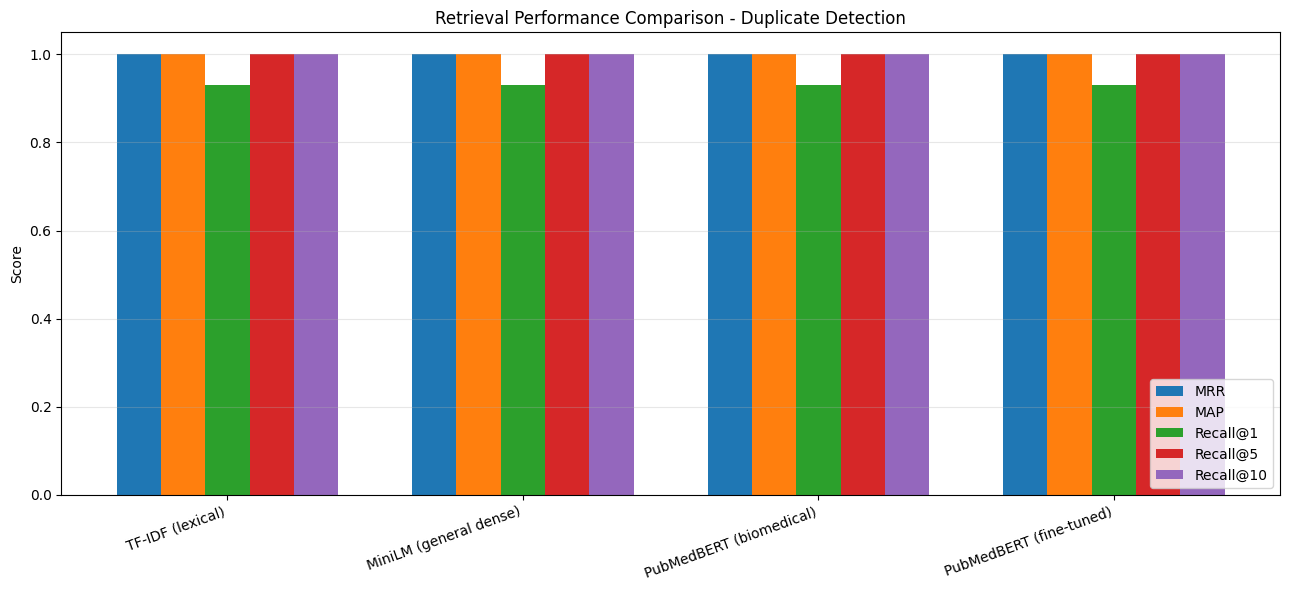

In [25]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(13, 6))
metrics = ['MRR', 'MAP', 'Recall@1', 'Recall@5', 'Recall@10']
approaches = list(all_results.keys())
x = np.arange(len(approaches))
width = 0.15
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, metric in enumerate(metrics):
    values = [all_results[name][metric] for name in approaches]
    ax.bar(x + i*width, values, width, label=metric, color=colors[i])

ax.set_xticks(x + width * (len(metrics)-1) / 2)
ax.set_xticklabels(approaches, rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_title('Retrieval Performance Comparison - Duplicate Detection')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

***
## Section 11: Qualitative Analysis — Where Does Each Approach Win or Lose?

In [26]:
# Per-query MRR for each approach - find where they agree/disagree
def per_query_rr(corpus_matrix, query_df, corpus_df, is_sparse=False):
    '''Return per-query reciprocal rank of the first relevant retrieval.'''
    rowid_to_pos = {rid: i for i, rid in enumerate(corpus_df['row_id'].values)}
    corpus_ids = corpus_df['row_id'].values
    rrs = []
    for _, q in query_df.iterrows():
        q_pos = rowid_to_pos[q['query_row_id']]
        rel = set(q['relevant_row_ids'])
        if is_sparse:
            q_vec = corpus_matrix[q_pos]
        else:
            q_vec = corpus_matrix[q_pos:q_pos+1]
        sims = cosine_similarity(q_vec, corpus_matrix).flatten()
        sims[q_pos] = -np.inf
        ranked = corpus_ids[np.argsort(-sims)]
        rr = 0.0
        for rank, rid in enumerate(ranked, start=1):
            if rid in rel:
                rr = 1.0 / rank
                break
        rrs.append(rr)
    return np.array(rrs)

print('Computing per-query RRs...')
rr_tfidf = per_query_rr(tfidf_matrix, query_df, combined_df, is_sparse=True)
rr_minilm = per_query_rr(embeddings_minilm, query_df, combined_df)
rr_pubmed = per_query_rr(embeddings_pubmed, query_df, combined_df)
rr_ft = per_query_rr(embeddings_finetuned, query_df, combined_df)

per_query_df = query_df[['query_abstract', 'query_condition', 'num_relevant']].copy()
per_query_df['RR_tfidf'] = rr_tfidf
per_query_df['RR_minilm'] = rr_minilm
per_query_df['RR_pubmed'] = rr_pubmed
per_query_df['RR_finetuned'] = rr_ft
print('Done.')

Computing per-query RRs...
Done.


In [27]:
# Where does fine-tuning help the most vs pretrained PubMedBERT?
per_query_df['ft_improvement'] = per_query_df['RR_finetuned'] - per_query_df['RR_pubmed']
biggest_gains = per_query_df.nlargest(3, 'ft_improvement')

print('Queries where fine-tuning helped PubMedBERT the most:')
for _, row in biggest_gains.iterrows():
    print(f'\n  Condition: {row["query_condition"]}')
    print(f'  Abstract (truncated): {row["query_abstract"][:160]}...')
    print(f'  RR - pre-trained PubMedBERT: {row["RR_pubmed"]:.4f}')
    print(f'  RR - fine-tuned PubMedBERT:  {row["RR_finetuned"]:.4f}')
    print(f'  Improvement: +{row["ft_improvement"]:.4f}')

Queries where fine-tuning helped PubMedBERT the most:

  Condition: nervous system diseases
  Abstract (truncated): Obstructive sleep apnea following topical oropharyngeal anesthesia in loud snorers. Previous studies support the presence of an upper airway reflex mechanism th...
  RR - pre-trained PubMedBERT: 1.0000
  RR - fine-tuned PubMedBERT:  1.0000
  Improvement: +0.0000

  Condition: general pathological conditions
  Abstract (truncated): Neutrophil function and pyogenic infections in bone marrow transplant recipients. In a consecutive entry trial, the incidence and time course of decreased neutr...
  RR - pre-trained PubMedBERT: 1.0000
  RR - fine-tuned PubMedBERT:  1.0000
  Improvement: +0.0000

  Condition: general pathological conditions
  Abstract (truncated): A phase II study of combined methotrexate and teniposide infusions prior to reinduction therapy in relapsed childhood acute lymphoblastic leukemia: a Pediatric ...
  RR - pre-trained PubMedBERT: 1.0000
  RR - fine-tune

In [28]:
# Where do dense embeddings beat TF-IDF (semantic wins)?
per_query_df['dense_over_tfidf'] = per_query_df['RR_finetuned'] - per_query_df['RR_tfidf']
semantic_wins = per_query_df[per_query_df['dense_over_tfidf'] > 0.3].head(3)

print('Queries where fine-tuned dense embeddings beat TF-IDF substantially:')
print('(These are cases where semantic matching beats lexical matching)')
for _, row in semantic_wins.iterrows():
    print(f'\n  Condition: {row["query_condition"]}')
    print(f'  Abstract (truncated): {row["query_abstract"][:160]}...')
    print(f'  RR - TF-IDF:      {row["RR_tfidf"]:.4f}')
    print(f'  RR - fine-tuned:  {row["RR_finetuned"]:.4f}')

Queries where fine-tuned dense embeddings beat TF-IDF substantially:
(These are cases where semantic matching beats lexical matching)


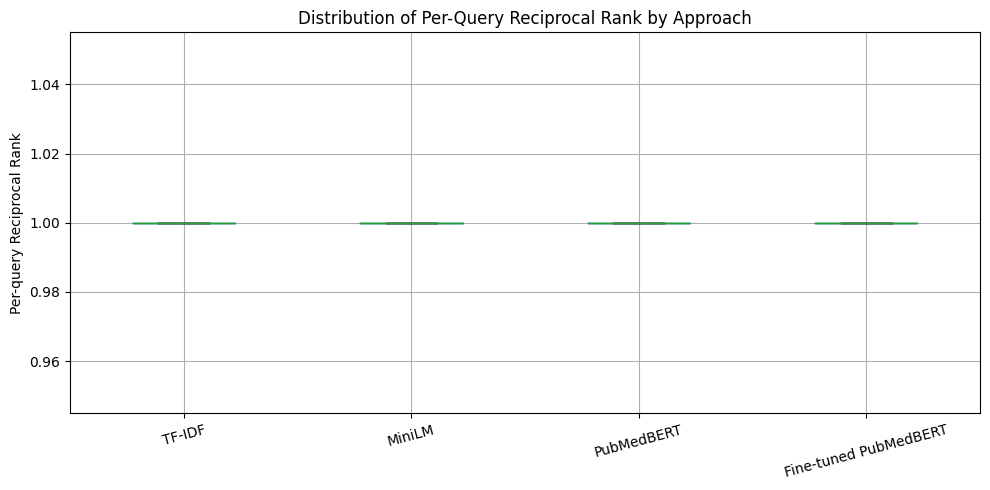


Proportion of queries achieving perfect top-1 retrieval (RR = 1.0):
  TF-IDF: 100.0%
  MiniLM: 100.0%
  PubMedBERT: 100.0%
  Fine-tuned PubMedBERT: 100.0%


In [29]:
# Distribution of per-query MRR for each approach (boxplot)
rr_data = pd.DataFrame({
    'TF-IDF': rr_tfidf,
    'MiniLM': rr_minilm,
    'PubMedBERT': rr_pubmed,
    'Fine-tuned PubMedBERT': rr_ft,
})

fig, ax = plt.subplots(figsize=(10, 5))
rr_data.boxplot(ax=ax)
ax.set_ylabel('Per-query Reciprocal Rank')
ax.set_title('Distribution of Per-Query Reciprocal Rank by Approach')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# Fraction of queries where each approach achieves RR = 1.0 (perfect top-1 retrieval)
print('\nProportion of queries achieving perfect top-1 retrieval (RR = 1.0):')
for col in rr_data.columns:
    perfect = (rr_data[col] == 1.0).mean()
    print(f'  {col}: {perfect*100:.1f}%')

***
## Section 12: Business Case Framing Notes

**For the report write-up, translate retrieval metrics into MediPublish-relevant language:**

- **Recall@5** answers: *"For a new article submission, what fraction of the time will a reviewer see at least one known duplicate in the top 5 most-similar articles returned?"*
- **MRR** answers: *"On average, how high up the ranked list does the first duplicate appear?"* - directly informs the UI design (how many results a reviewer needs to scan).
- **MAP** answers: *"How well are ALL duplicates surfaced, not just the first one?"* - important when one article has multiple near-duplicates in the database.

**Business trade-offs to discuss:**

- **Recall-vs-precision for MediPublish:** missing a duplicate (false negative) means publishing overlapping content - reputational and possibly legal risk. Surfacing a false duplicate (false positive) means reviewer time spent checking. MediPublish almost certainly prefers high recall.
- **Deployment cost:** TF-IDF runs on CPU with negligible infrastructure. Dense embeddings need GPU for encoding (though retrieval itself is cheap with FAISS or similar indexes). Fine-tuned models add a one-time training cost.
- **When TF-IDF suffices:** if the evaluation shows TF-IDF achieves high recall, MediPublish may not need the infrastructure for dense embeddings. The comparison quantifies this explicitly.

**Recommendation framework based on results:**

*(Fill in after seeing final numbers)* - if TF-IDF achieves ≥0.95 Recall@5, the pragmatic recommendation is TF-IDF with a dense-embedding review layer only for borderline cases. If fine-tuned PubMedBERT shows meaningful gains on paraphrased/semantic cases, full dense retrieval is justified.

***
## GenAI Statement

GenAI was used to support completion of this assessment.

Specifically:
- **Ideas:** discussing retrieval approaches, evaluation metrics, and the methodology of constructing hard-negative training pairs for contrastive fine-tuning.
- **Editing:** reviewing code for correctness, consistency between cells, and alignment between the notebook narrative and the report.

All code was written and executed by me. All report text was written by me.